# Handwritten Digit Classification on MNIST Using Artificial Neural Network (MLP)

## Objective
The goal of this project is to classify handwritten digit images from the MNIST dataset using an Artificial Neural Network (ANN) based on a Multi-Layer Perceptron (MLP).

## About the Dataset
The MNIST dataset contains grayscale images of handwritten digits from 0 to 9.
- Training samples: 60,000
- Testing samples: 10,000
- Image size: 28 x 28 pixels
- Number of classes: 10

## Workflow
1. Import required libraries
2. Load the MNIST dataset
3. Visualize sample digit images
4. Preprocess the data
5. Build the ANN (MLP) model
6. Compile and train the model
7. Evaluate model performance
8. Visualize predictions and summarize results

In [1]:
# Step 1 - Import basic and necessary Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from warnings import filterwarnings
filterwarnings('ignore')
%matplotlib inline

## Step 1 - Import Required Libraries

We use:
- **NumPy** → for numerical operations
- **Pandas** → for structured data handling if needed
- **Matplotlib** → for plotting digit images and training curves
- **Seaborn** → for better plot styling
- **TensorFlow / Keras** → for building and training the ANN model

In [2]:
# Step 2 - Load dataset

from tensorflow import keras
from tensorflow.keras import layers

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print("x_train shape :", x_train.shape)
print("y_train shape :", y_train.shape)
print("x_test shape  :", x_test.shape)
print("y_test shape  :", y_test.shape)

x_train shape : (60000, 28, 28)
y_train shape : (60000,)
x_test shape  : (10000, 28, 28)
y_test shape  : (10000,)


## Step 2 - Dataset Understanding

After loading the dataset:
- `x_train` and `x_test` contain image pixel data
- `y_train` and `y_test` contain digit labels
- Each image is a 28 x 28 grayscale image
- Since this is a multi-class classification problem, the output classes are digits from 0 to 9

## Step 3 - Visualize Sample Images

Before training the model, we inspect a few handwritten digit images from the training set to understand the type of input data.

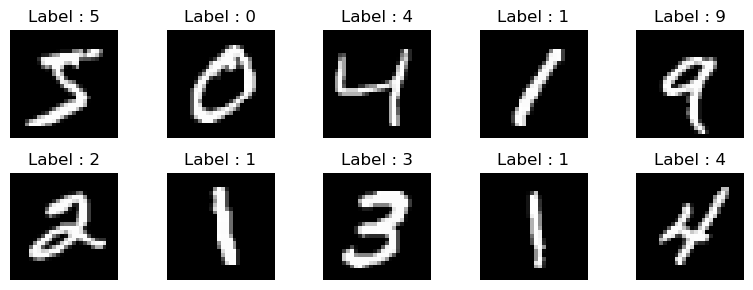

In [3]:
# Step 3 - Basic Visualization

plt.figure(figsize = (8,3))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train[i], cmap = 'gray')
    plt.title(f"Label : {y_train[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [4]:
# Step 4 - Preprocessing: scaling, flattening, and one-hot encoding

# Scale pixel values from [0, 255] to [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Flatten 28x28 images into 784-dimensional vectors
x_train = x_train.reshape(-1, 28 * 28)
x_test = x_test.reshape(-1, 28 * 28)

num_classes = 10

# One-hot encode target labels
y_train_cat = keras.utils.to_categorical(y_train, num_classes)
y_test_cat = keras.utils.to_categorical(y_test, num_classes)

print("Processed x_train shape :", x_train.shape)
print("Processed x_test shape  :", x_test.shape)
print("One-hot y_train shape   :", y_train_cat.shape)
print("One-hot y_test shape    :", y_test_cat.shape)

Processed x_train shape : (60000, 784)
Processed x_test shape  : (10000, 784)
One-hot y_train shape   : (60000, 10)
One-hot y_test shape    : (10000, 10)


## Step 4 - Why Preprocessing is Needed

Preprocessing is necessary for the following reasons:

- **Scaling:** Pixel values originally range from 0 to 255. Dividing by 255 brings them into the range [0, 1], which helps the neural network train more efficiently.
- **Flattening:** An MLP model expects a one-dimensional feature vector as input, so each 28 x 28 image is reshaped into a vector of 784 values. (MLP needs vectors, not 2D images.) Flatten is just reshaping the image into that vector so the MLP can use it.
- **One-hot encoding:** Since this is a multi-class classification problem, labels are converted into one-hot encoded form for use with categorical cross-entropy loss.

### Q. Why we usually don’t use StandardScaler for MNIST images :-

- MNIST pixel values are already in a fixed range 0–255 and represent intensity.

- For neural networks, the typical practice is to put inputs into a bounded range, like or [-1,1], which keeps gradients stable and training faster.

- The simplest way to do that for images is x / 255.0, which Keras examples explicitly recommend for MNIST and similar image datasets.

In [5]:
# Step 5 - Define the ANN (MLP) model

model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(784,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

## Step 5 - Model Architecture

The ANN model used in this project consists of:
- An input layer that accepts 784 features
- A first hidden layer with 128 neurons and ReLU activation
- A second hidden layer with 64 neurons and ReLU activation
- An output layer with 10 neurons and Softmax activation for multi-class classification

In [6]:
# Step 6 - Model Compile

model.compile(
    optimizer = 'adam',
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)

## Step 6 - Model Compilation

The model is compiled using:
- **Adam optimizer** → for adaptive learning
- **Categorical cross-entropy** → as the loss function, suitable for multi-class classification
- **Accuracy** → as the evaluation metric

In [7]:
# Step 7 - Train the model and store training history

history = model.fit(
    x_train,
    y_train_cat,
    validation_split = 0.1,
    epochs = 10,
    batch_size = 128,
    verbose = 1                  # verbose=1 → progress bar + metrics per epoch 
)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9013 - loss: 0.3503 - val_accuracy: 0.9623 - val_loss: 0.1459
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9574 - loss: 0.1451 - val_accuracy: 0.9672 - val_loss: 0.1153
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9694 - loss: 0.1029 - val_accuracy: 0.9713 - val_loss: 0.1016
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9764 - loss: 0.0778 - val_accuracy: 0.9765 - val_loss: 0.0854
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9814 - loss: 0.0621 - val_accuracy: 0.9772 - val_loss: 0.0832
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9841 - loss: 0.0500 - val_accuracy: 0.9753 - val_loss: 0.0824
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9884 - loss: 0.0387 - val_accuracy: 0.9795 - val_loss: 0.0816
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9906 - loss: 0.0315 - val_accuracy: 0

## Step 7 - Training Process

During training:
- The model is trained for `10 epochs`
- Batch size is set to `128`
- `10%` of the training data is used for validation
- The `history` object stores training and validation accuracy/loss values for later visualization

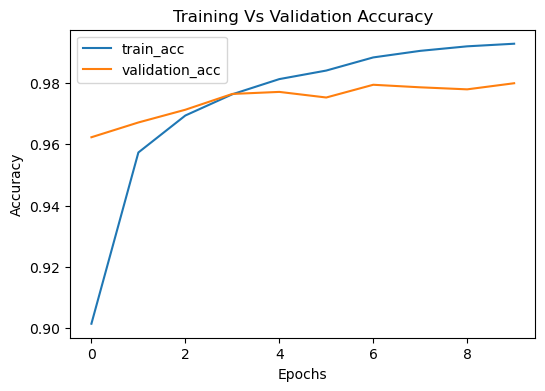

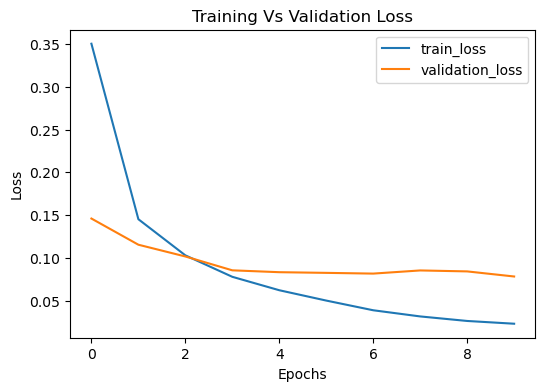

In [8]:
# Step 8 - Plot training and validation curves

## Accuracy

plt.figure(figsize = (6,4))
plt.plot(history.history['accuracy'], label = 'train_acc')
plt.plot(history.history['val_accuracy'], label = 'validation_acc')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training Vs Validation Accuracy')
plt.savefig('Output_images\Accuracy Plot.png', dpi = 300, bbox_inches = 'tight')
plt.show()


## Loss

plt.figure(figsize = (6,4))
plt.plot(history.history['loss'], label = 'train_loss')
plt.plot(history.history['val_loss'], label = 'validation_loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training Vs Validation Loss')
plt.savefig('Output_images\Loss Plot.png', dpi = 300, bbox_inches = 'tight')
plt.show()

In [9]:
# Step 9 - Evaluate the model on test data

test_loss, test_accuracy = model.evaluate(x_test, y_test_cat, verbose=0)  # verbose=0 → silent(no progress printed)

print("Test Loss     :", round(test_loss, 4))
print("Test Accuracy :", round(test_accuracy, 4))

Test Loss     : 0.0792
Test Accuracy : 0.9762


## Step 9 - Test Performance

After training, the model is evaluated on unseen test data to measure its generalization performance. Test accuracy gives an estimate of how well the trained ANN can classify handwritten digits it has not seen before.

In [10]:
# Step 10 - Generate predictions

y_pred_proba = model.predict(x_test)
y_pred = np.argmax(y_pred_proba, axis = 1)

print("First 10 predicted labels :", y_pred[:10])
print("First 10 actual labels    :", y_test[:10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
First 10 predicted labels : [7 2 1 0 4 1 4 9 6 9]
First 10 actual labels    : [7 2 1 0 4 1 4 9 5 9]


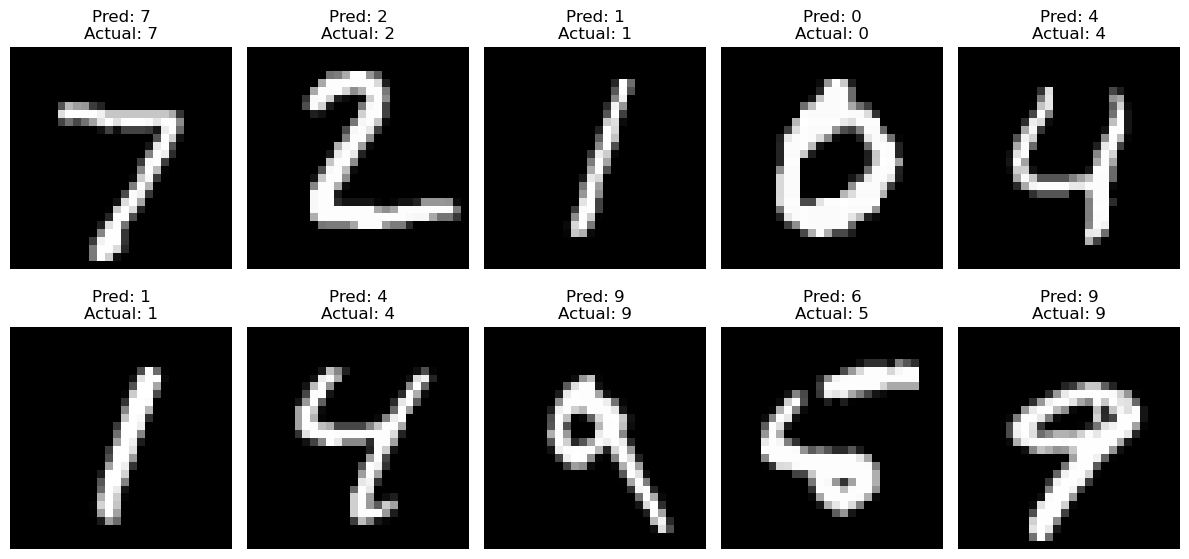

In [11]:
# Step 11 - Visualize a few predictions

plt.figure(figsize=(12, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title(f"Pred: {y_pred[i]}\nActual: {y_test[i]}")
    plt.axis('off')

plt.tight_layout()
plt.savefig('Output_images\Visual Predictions.png', dpi = 300, bbox_inches = 'tight')
plt.show()

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.97      0.98      0.97      1032
           3       0.97      0.95      0.96      1010
           4       0.97      0.97      0.97       982
           5       0.96      0.98      0.97       892
           6       0.98      0.98      0.98       958
           7       0.98      0.97      0.98      1028
           8       0.97      0.97      0.97       974
           9       0.97      0.98      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



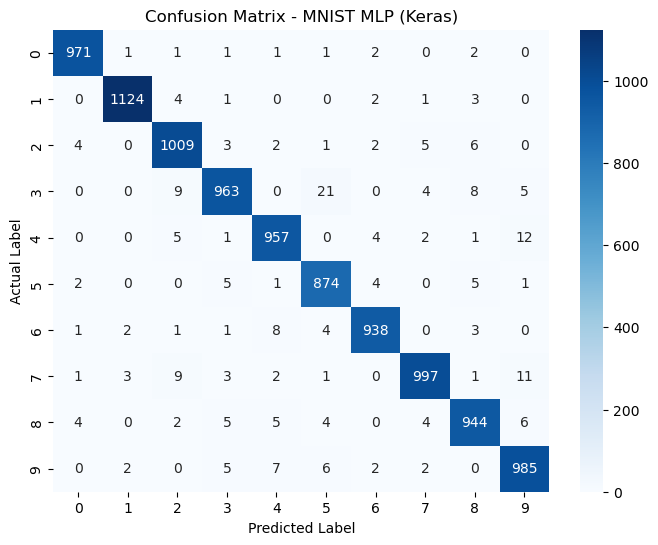

In [12]:
# Step 12 - Classification report and Confusion matrix

from sklearn.metrics import classification_report, confusion_matrix

print("Classification Report:\n")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix - MNIST MLP (Keras)')
plt.savefig('Output_images\Confusion Matrix MNIST ANN.png', dpi = 300, bbox_inches = 'tight')
plt.show()

## Report of ANN model :-

#### Title & Objective :-

“Classify handwritten digits (0–9) using an Artificial Neural Network (MLP) on the MNIST dataset.”

#### Dataset description :-

Size = 70,000 images, image shape = 28 × 28 pixels, number of classes = 10, source = Keras MNIST dataset.

#### Preprocessing :-

Scaling input pixel values to a suitable range, flattening each image to 784 features, and converting labels to one-hot encoded format.

#### Model architecture :-

ANN model with 2 hidden layers.  
Activation functions = ReLU for hidden layers and Softmax for output layer only.  
Optimizer = Adam, loss function = categorical cross-entropy.

#### Training details :-

Epochs = 10, batch size = 128, validation split = 0.1 (10% of training data used for validation).

#### Results :-

Test accuracy ≈ 97.62%.  
Confusion matrix and sample predictions show that most digits are classified correctly.  
Training and validation curves indicate that the model is learning well without severe overfitting.

#### Observations :-

“ANN achieved around 97–98% accuracy on the test set, which satisfies the objective very well.”  
I observe that digit **5** is misclassified more times according to the confusion matrix, maybe because of the handwriting pattern of that digit, which can look similar to other digits.

## Conclusion

In this project, an Artificial Neural Network (MLP) was built to classify handwritten digits from the MNIST dataset.  
The dataset was preprocessed by scaling pixel values, flattening image matrices, and one-hot encoding the labels.  
The trained model achieved strong performance on the test data, showing that ANN-based MLP models can perform very well on basic image classification tasks.

### Key Learnings
- Neural networks require proper preprocessing before training
- MLP models can work effectively for simple image classification problems
- Training and validation curves help in understanding model performance
- Confusion matrix and classification report provide deeper evaluation insight

### Future Improvement
A Convolutional Neural Network (CNN) can be used in the future to achieve even better performance because CNNs are more suitable for image data.